# MediaPipe

In [13]:
import cv2
import mediapipe as mp
import pandas as pd
import matplotlib.pyplot as plt

BaseOptions = mp.tasks.BaseOptions
PoseLandmarker = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

Doc : https://developers.google.com/edge/mediapipe/solutions/vision/pose_landmarker/python

Here we also need to download a model on the shelf, cf : https://developers.google.com/edge/mediapipe/solutions/vision/pose_landmarker#models </br>
I will be using the Pose landmarker full.

## Using MediaPipe

In [8]:
model_path = "../models/pose_landmarker_full.task"

options = PoseLandmarkerOptions(base_options = BaseOptions(model_asset_path=model_path), running_mode=VisionRunningMode.VIDEO)

landmarker = mp.tasks.vision.PoseLandmarker.create_from_options(options)

Unlike Yolo, MediaPipe does not directly read a video file. I will use OpenCV to open the .mov and send every frame to MediaPipe.

In [9]:
video_path = "../assets/backflip.mov"

cap = cv2.VideoCapture(video_path)
success, frame = cap.read()
cap.release()

print(success) # OpenCV read the file successfully
print(frame.shape)


True
(1920, 1080, 3)


### Read one frame

In [10]:
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# np array to mp Image
mp_image = mp.Image(image_format = mp.ImageFormat.SRGB, data = frame_rgb)

result = landmarker.detect_for_video(mp_image,timestamp_ms=0)
print(result)

PoseLandmarkerResult(pose_landmarks=[[NormalizedLandmark(x=0.5955667495727539, y=0.2589302062988281, z=-0.030173562467098236, visibility=0.9995260238647461, presence=0.9998131394386292, name=None), NormalizedLandmark(x=0.5960955619812012, y=0.25018131732940674, z=-0.013221642933785915, visibility=0.9988565444946289, presence=0.9996861219406128, name=None), NormalizedLandmark(x=0.5953032970428467, y=0.24973583221435547, z=-0.013250146992504597, visibility=0.9982821941375732, presence=0.9996519088745117, name=None), NormalizedLandmark(x=0.5942181348800659, y=0.24925555288791656, z=-0.013287766836583614, visibility=0.9989135265350342, presence=0.999591052532196, name=None), NormalizedLandmark(x=0.5941230058670044, y=0.24978607892990112, z=-0.06530360132455826, visibility=0.9992882609367371, presence=0.9997784495353699, name=None), NormalizedLandmark(x=0.5917835831642151, y=0.249064102768898, z=-0.0652535930275917, visibility=0.9992902278900146, presence=0.9997761845588684, name=None), Nor

This model is stateful, meaning it keeps information from previous frames to track the pose over time. Therefore each new frame must have a timestamp greater than the previous one.

### Read multiple frames

In [11]:
LANDMARKS = [
    "nose",
    "left_eye_inner",
    "left_eye",
    "left_eye_outer",
    "right_eye_inner",
    "right_eye",
    "right_eye_outer",
    "left_ear",
    "right_ear",
    "mouth_left",
    "mouth_right",
    "left_shoulder",
    "right_shoulder",
    "left_elbow",
    "right_elbow",
    "left_wrist",
    "right_wrist",
    "left_pinky",
    "right_pinky",
    "left_index",
    "right_index",
    "left_thumb",
    "right_thumb",
    "left_hip",
    "right_hip",
    "left_knee",
    "right_knee",
    "left_ankle",
    "right_ankle",
    "left_heel",
    "right_heel",
    "left_foot_index",
    "right_foot_index"
]

In [ ]:
video_path = "../assets/backflip.mov"

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)

rows = []
frame_index = 0

with PoseLandmarker.create_from_options(options) as landmarker:

    while True:
    
        success, frame = cap.read()

        if not success:
            break

        # open frame with opencv
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

       # np array to mp Image
        mp_image = mp.Image(image_format = mp.ImageFormat.SRGB, data = frame_rgb)

        #timestamp
        timestamp_ms = int(frame_index*1000/fps)

       # inference
        result = landmarker.detect_for_video(mp_image,timestamp_ms=timestamp_ms)

        # pose detected
        if result.pose_landmarks:

            # first person detected
            pose = result.pose_landmarks[0]

            # keeping the 33 landmarks
            for i, landmark in enumerate(pose):

                rows.append({
                    "frame": frame_index,
                    "time": frame_index / fps,
                    "keypoint": LANDMARKS[i],
                    "x": landmark.x,
                    "y": landmark.y,
                    "z": landmark.z,
                    "visibility": landmark.visibility, # model thinks landmark is clearly visible in the image
                    "presence": landmark.presence # model thinks landmark exists in the image
                })


        frame_index += 1

cap.release()

df_mp = pd.DataFrame(rows)

display(df_mp.head())
print(df_mp.shape)

,frame,time,keypoint,x,y,z,visibility,presence
0,0,0.0,nose,0.595567,0.258930,-0.030174,0.999526,0.999813
1,0,0.0,left_eye_inner,0.596096,0.250181,-0.013222,0.998857,0.999686
2,0,0.0,left_eye,0.595303,0.249736,-0.013250,0.998282,0.999652
3,0,0.0,left_eye_outer,0.594218,0.249256,-0.013288,0.998914,0.999591
4,0,0.0,right_eye_inner,0.594123,0.249786,-0.065304,0.999288,0.999778


(3927, 8)


## Visualization

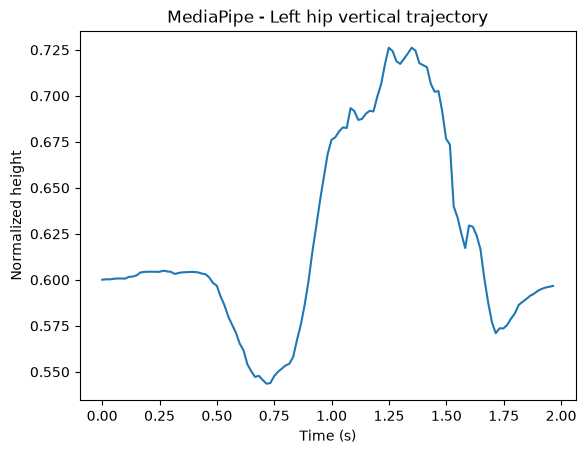

In [ ]:
hip = df_mp[df_mp["keypoint"] == "left_hip"]

plt.plot(hip["time"],1 - hip["y"])

plt.xlabel("Time (s)")
plt.ylabel("Normalized height")
plt.title("MediaPipe - Left hip vertical trajectory")

plt.show()